In [2]:
!pip install librosa soundfile numpy matplotlib scikit-learn tensorflow

In [3]:
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models


In [4]:
SAMPLE_RATE = 16000
DURATION = 1        # seconds
SAMPLES = SAMPLE_RATE * DURATION

N_MFCC = 20
N_FFT = 512
HOP_LENGTH = 160
N_MELS = 40


In [5]:
!wget http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
!tar -xzf speech_commands_v0.02.tar.gz


--2025-12-18 08:17:11--  http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 142.250.101.207, 142.251.2.207, 74.125.137.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.250.101.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  91.2MB/s    in 15s     

2025-12-18 08:17:26 (150 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923189/2428923189]



In [6]:
KEYWORDS = ['yes','no','on','off','up','down','left','right']

LABEL_MAP = {
    'yes':0,
    'no':1,
    'on':2,
    'off':3,
    'up':4,
    'down':5,
    'left':6,
    'right':7,
    'unknown':8,
    'silence':9
}

NUM_CLASSES = 10


In [7]:
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    if len(audio) < SAMPLES:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))
    else:
        audio = audio[:SAMPLES]

    audio = audio / np.max(np.abs(audio) + 1e-9)
    return audio

In [8]:
def extract_mfcc(audio):
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    return mfcc


In [9]:
X = []
y = []

for word in KEYWORDS:
    folder = word
    files = os.listdir(folder)

    for file in files:
        file_path = os.path.join(folder, file)
        audio = preprocess_audio(file_path)
        mfcc = extract_mfcc(audio)

        X.append(mfcc)
        y.append(LABEL_MAP[word])


In [10]:
all_words = os.listdir()

# keep only directories
all_words = [
    w for w in all_words
    if os.path.isdir(w)
]

unknown_words = list(
    set(all_words)
    - set(KEYWORDS)
    - {'_background_noise_'}
)

unknown_words = random.sample(unknown_words, 5)


In [11]:
bg_folder = '_background_noise_'

for file in os.listdir(bg_folder):

    if not file.endswith('.wav'):
        continue   # skip README.md and others

    noise, sr = librosa.load(
        os.path.join(bg_folder, file),
        sr=SAMPLE_RATE
    )

    for i in range(20):
        start = random.randint(0, len(noise) - SAMPLES)
        chunk = noise[start:start + SAMPLES]
        mfcc = extract_mfcc(chunk)

        X.append(mfcc)
        y.append(LABEL_MAP['silence'])



In [12]:
X = np.array(X)
y = np.array(y)

X = X[..., np.newaxis]  # (samples, 20, frames, 1)

y = tf.keras.utils.to_categorical(y, NUM_CLASSES)

print(X.shape, y.shape)


(30914, 20, 101, 1) (30914, 10)


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [14]:
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 99, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 99, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 49, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 47, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 47, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 23, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2208)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       282,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,034 (1.10 MB)

 Trainable params: 288,938 (1.10 MB)

 Non-trainable params: 96 (384.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val)
)


Epoch 1/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.3633 - loss: 1.7729 - val_accuracy: 0.7227 - val_loss: 0.7972
Epoch 2/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6562 - loss: 0.9360 - val_accuracy: 0.8088 - val_loss: 0.5376
Epoch 3/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7527 - loss: 0.6947 - val_accuracy: 0.8538 - val_loss: 0.4164
Epoch 4/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8123 - loss: 0.5339 - val_accuracy: 0.8615 - val_loss: 0.4142
Epoch 5/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8375 - loss: 0.4605 - val_accuracy: 0.8932 - val_loss: 0.3146
Epoch 6/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8608 - loss: 0.4048 - val_accuracy: 0.8984 - val_loss: 0.3209
Epoch 7/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8731 - loss: 0.3592 - val_accuracy: 0.9068 - val_loss: 0.2843
Epoch 8/40
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8854 - loss: 0.3280 - val_accuracy:

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9242 - loss: 0.3085
Test Accuracy: 0.9194695949554443


In [18]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_labels))


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       412
           1       0.88      0.92      0.90       392
           2       0.90      0.94      0.92       380
           3       0.92      0.86      0.89       385
           4       0.87      0.91      0.89       370
           5       0.92      0.91      0.91       404
           6       0.93      0.91      0.92       369
           7       0.96      0.96      0.96       370
           9       1.00      0.90      0.95        10

    accuracy                           0.92      3092
   macro avg       0.93      0.92      0.92      3092
weighted avg       0.92      0.92      0.92      3092



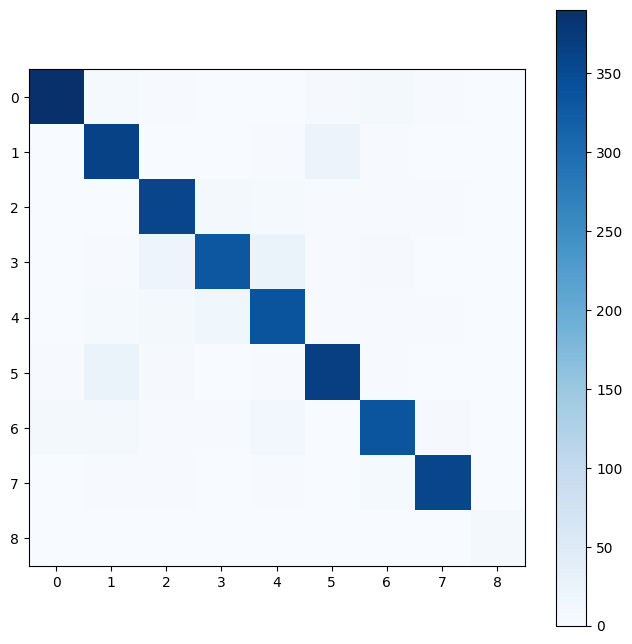

In [19]:
cm = confusion_matrix(y_true, y_pred_labels)
plt.figure(figsize=(8,8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.show()


In [20]:
model.save("kws_mfcc_cnn.h5")


In [21]:
from google.colab import files
files.download("kws_mfcc_cnn.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>